# Simple Dust Attenuation

> Exploring simpler, direct parameterizations as drop-in replacements for DustE

## Motivation

The current `spectrum_dusted()` function uses the DustE library (Nagaraj+22), which involves:
1. Pre-computed hierarchical Bayesian trace files from fitting ~30,000 3D-HST galaxies with Prospector SED-fitting
2. 5D interpolation in `(logM, SFR, logZ, z, inclination)` parameter space
3. Sampling from posterior distributions with scatter
4. Marginalization over unavailable parameters (SFR, inclination)

**Key insight**: The actual attenuation *physics* inside DustE is just two well-known analytic functions.  
All the Bayesian machinery only predicts 2–3 dust parameters from galaxy properties.  
We can bypass the full machinery by parameterizing dust directly.

**Critical limitation of DustE for our use case**:  
The training sample spans `z = 0.51–2.83`. Our HACC simulation galaxies at `z ~ 0.001` are far  
outside this range — DustE is extrapolating, not interpolating.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sedpy.attenuation import noll
import warnings
warnings.filterwarnings('ignore')

---
## 1. Anatomy of DustE: What It Actually Computes

DustE maps galaxy properties → dust parameters → attenuation curves.  
The attenuation step uses exactly two functions:

### Component 1: Diffuse ISM dust (Noll+09 modified Calzetti law)

```
τ_ISM(λ) = Noll(λ, τ_V=τ₂, δ=n, E_bump = 0.85 − 1.9n)
```

- `τ₂` = diffuse V-band optical depth (0–2 for typical galaxies)
- `n` (= δ in Noll+09) = slope modifier; `n=0` → pure Calzetti; `n<0` → steeper UV
- `E_bump` = UV 2175 Å bump strength, tied to slope by `0.85 − 1.9n`
- **Applies to ALL stellar populations** (old + young)

### Component 2: Birth cloud dust (Charlot & Fall 2000)

```
τ_BC(λ) = τ₁ × (λ / 5500 Å)^{−1}
```

- `τ₁` = birth cloud optical depth; steeper power-law than ISM
- **Applies only to young stars** (age < ~10 Myr in CF00; in DustE, to the whole young SFR component)
- In DustE's bivariate model: `τ₁` is derived from `τ₂` via a separate interpolation

### Final attenuation factor

```
f(λ) = exp(−τ_ISM(λ)) × exp(−τ_BC(λ))
L_dusted(λ) = L_CSP(λ) × f(λ)
```

That's it. Everything else in DustE is about predicting (n, τ₂, τ₁).

In [ ]:

# ── Direct implementations of DustE's two internal functions ──────────────────

def tau_noll(wave, tau_V, n=0.0):
    """Diffuse ISM attenuation (Noll+09 modified Calzetti law).
    
    Identical to DustE's get_dust_attn_curve_d2(wave, n=n, d2=tau_V).
    Uses sedpy.attenuation.noll internally.
    
    IMPORTANT: DustE ties the UV 2175 Å bump to the slope via Ebump = 0.85 - 1.9*n.
    At n=0, Ebump=0.85 (bump IS present). This is NOT pure Calzetti (which has no bump).
    At n ≈ +0.45, Ebump→0 (bump disappears).
    Use tau_calzetti() for pure Calzetti with no bump.
    
    Parameters
    ----------
    wave  : array, wavelengths in Angstroms
    tau_V : float, V-band optical depth (DustE's τ₂ / d2 parameter)
    n     : float, slope modification; n<0 → steeper UV
            typical range: −1.0 to +0.4
    
    Returns
    -------
    tau_lambda : array, optical depth at each wavelength
    """
    Ebump = 0.85 - 1.9 * n          # UV bump strength (Noll+09); Ebump=0 at n≈0.447
    return noll(wave, tau_v=tau_V, delta=n, c_r=0.0, Ebump=Ebump)


def tau_charlot_fall(wave, tau1):
    """Birth cloud attenuation (Charlot & Fall 2000 power law).
    
    Identical to DustE's get_dust_attn_curve_d1(wave, d1=tau1).
    Uses exponent −1 (steeper than the CF00 ISM exponent of −0.7).
    
    Parameters
    ----------
    wave  : array, wavelengths in Angstroms
    tau1  : float, birth cloud optical depth at reference wavelength 5500 Å
    
    Returns
    -------
    tau_lambda : array, optical depth at each wavelength
    """
    return tau1 * (wave / 5500.0) ** (-1.0)


# Quick sanity check: at V-band (5500 Å), tau should equal tau_V
w_test = np.array([1500., 2175., 3000., 5500., 8000., 12000.])
print("tau_noll at test wavelengths (tau_V=0.5, n=0) — NOTE: UV bump at 2175 Å:")
for w, t in zip(w_test, tau_noll(w_test, 0.5, 0.0)):
    print(f"  {w:.0f} Å → tau = {t:.4f}")
print("\ntau_charlot_fall at test wavelengths (tau1=1.0):")
for w, t in zip(w_test, tau_charlot_fall(w_test, 1.0)):
    print(f"  {w:.0f} Å → tau = {t:.4f}")


tau_noll at test wavelengths (tau_V=0.5, n=0) — NOTE: UV bump at 2175 Å:
  1500 Å → tau = 1.2829
  2175 Å → tau = 1.1522
  3000 Å → tau = 0.8642
  5500 Å → tau = 0.5009
  8000 Å → tau = 0.3177
  12000 Å → tau = 0.1751

tau_charlot_fall at test wavelengths (tau1=1.0):
  1500 Å → tau = 3.6667
  2175 Å → tau = 2.5287
  3000 Å → tau = 1.8333
  5500 Å → tau = 1.0000
  8000 Å → tau = 0.6875
  12000 Å → tau = 0.4583


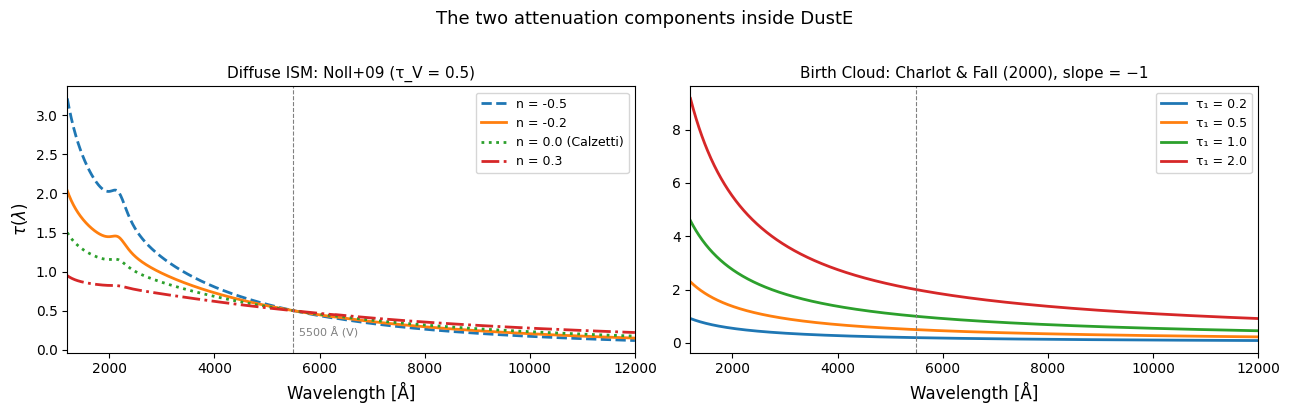

In [ ]:
# Visualize the two attenuation components
wave = np.linspace(1200, 12000, 1000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Panel 1: Diffuse ISM component (Noll+09) ---
ax = axes[0]
tau_V = 0.5
for n_val, ls in [(-0.5, '--'), (-0.2, '-'), (0.0, ':'), (0.3, '-.')] :
    tau = tau_noll(wave, tau_V, n_val)
    label = f'n = {n_val:.1f}' + (' (Calzetti)' if n_val==0 else '')
    ax.plot(wave, tau, ls=ls, lw=2, label=label)
ax.axvline(5500, color='gray', lw=0.8, ls='--')
ax.text(5600, ax.get_ylim()[1]*0.05 if ax.get_ylim()[1]>0 else 0.05, '5500 Å (V)', fontsize=8, color='gray')
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel(r'$\tau(\lambda)$', fontsize=12)
ax.set_title(f'Diffuse ISM: Noll+09 (τ_V = {tau_V})', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(1200, 12000)

# --- Panel 2: Birth cloud component (Charlot & Fall) ---
ax = axes[1]
for tau1 in [0.2, 0.5, 1.0, 2.0]:
    ax.plot(wave, tau_charlot_fall(wave, tau1), lw=2, label=f'τ₁ = {tau1}')
ax.axvline(5500, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_title('Birth Cloud: Charlot & Fall (2000), slope = −1', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(1200, 12000)

fig.suptitle('The two attenuation components inside DustE', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Parameter Sensitivity

Before choosing a simpler model, let's understand how each dust parameter affects the attenuation factor  
`f(λ) = exp(−τ_ISM) × exp(−τ_BC)` applied to a spectrum.

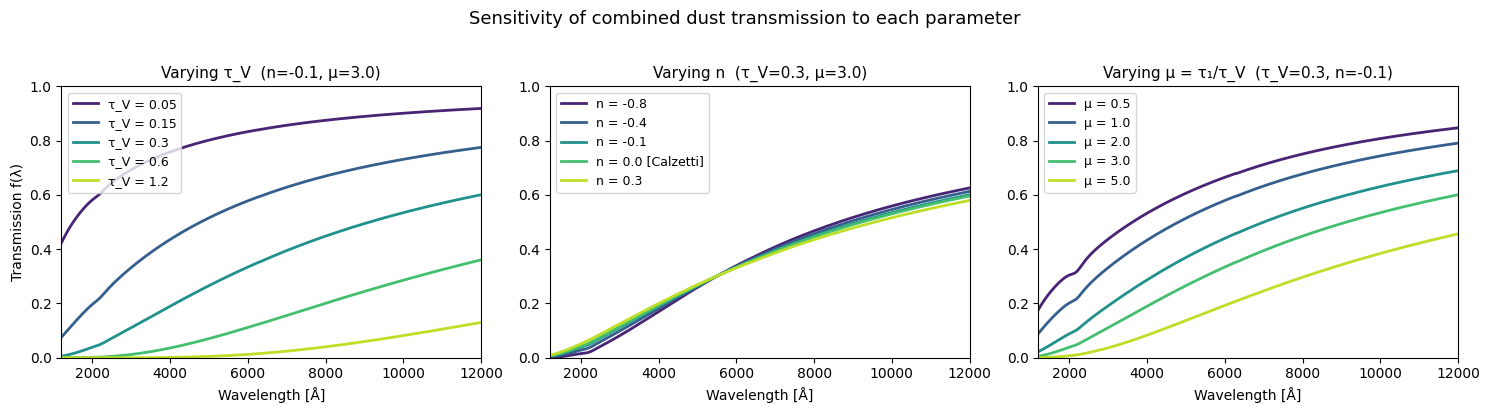

In [ ]:
wave = np.linspace(1200, 12000, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- τ_V sensitivity (n fixed, mu fixed) ---
ax = axes[0]
n_fixed, mu_fixed = -0.1, 3.0
colors = cm.viridis(np.linspace(0.1, 0.9, 5))
for tau_V, c in zip([0.05, 0.15, 0.3, 0.6, 1.2], colors):
    tau1 = mu_fixed * tau_V
    f = np.exp(-tau_noll(wave, tau_V, n_fixed)) * np.exp(-tau_charlot_fall(wave, tau1))
    ax.plot(wave, f, color=c, lw=2, label=f'τ_V = {tau_V}')
ax.set_title(f'Varying τ_V  (n={n_fixed}, μ={mu_fixed})', fontsize=11)
ax.set_xlabel('Wavelength [Å]'); ax.set_ylabel('Transmission f(λ)')
ax.legend(fontsize=9); ax.set_xlim(1200, 12000); ax.set_ylim(0, 1)

# --- n (slope) sensitivity (τ_V fixed, mu fixed) ---
ax = axes[1]
tau_V_fixed = 0.3
for n_val, c in zip([-0.8, -0.4, -0.1, 0.0, 0.3], colors):
    tau1 = mu_fixed * tau_V_fixed
    f = np.exp(-tau_noll(wave, tau_V_fixed, n_val)) * np.exp(-tau_charlot_fall(wave, tau1))
    label = f'n = {n_val}' + (' [Calzetti]' if n_val==0.0 else '')
    ax.plot(wave, f, color=c, lw=2, label=label)
ax.set_title(f'Varying n  (τ_V={tau_V_fixed}, μ={mu_fixed})', fontsize=11)
ax.set_xlabel('Wavelength [Å]')
ax.legend(fontsize=9); ax.set_xlim(1200, 12000); ax.set_ylim(0, 1)

# --- μ = τ₁/τ_V sensitivity (τ_V fixed, n fixed) ---
ax = axes[2]
n_fixed2 = -0.1
for mu, c in zip([0.5, 1.0, 2.0, 3.0, 5.0], colors):
    tau1 = mu * tau_V_fixed
    f = np.exp(-tau_noll(wave, tau_V_fixed, n_fixed2)) * np.exp(-tau_charlot_fall(wave, tau1))
    ax.plot(wave, f, color=c, lw=2, label=f'μ = {mu}')
ax.set_title(f'Varying μ = τ₁/τ_V  (τ_V={tau_V_fixed}, n={n_fixed2})', fontsize=11)
ax.set_xlabel('Wavelength [Å]')
ax.legend(fontsize=9); ax.set_xlim(1200, 12000); ax.set_ylim(0, 1)

fig.suptitle('Sensitivity of combined dust transmission to each parameter', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Takeaways from sensitivity analysis:**

- **τ_V** sets the overall attenuation level — this is the most important parameter
- **n** (slope) modifies the UV-to-optical *shape*, strongest effect at λ < 4000 Å
- **μ** (birth cloud ratio) adds extra UV suppression via the steeper power-law;  
  effect is most visible below ~3000 Å

For SEDs dominated by optical wavelengths (λ > 4000 Å), n and μ matter less —  
just getting τ_V right captures most of the effect.

---
## 3. Pure Calzetti Law — Simplest Possible Model

For maximum simplicity, we can implement the **Calzetti (2000)** law directly without sedpy.  
This is NOT the same as `tau_noll(n=0)` because:

- `tau_noll(n=0)` in DustE's convention: includes a UV 2175 Å bump with `Ebump = 0.85`
- Pure Calzetti: **no UV bump** (Calzetti et al. 2000 found no significant 2175 Å bump  
  in starburst galaxies, in contrast to the Milky Way extinction curve)

The Calzetti law has one parameter: **τ_V** (or equivalently E(B-V) = τ_V / 3.71).  
This is appropriate for optical/NIR studies where UV bump differences don't matter much.


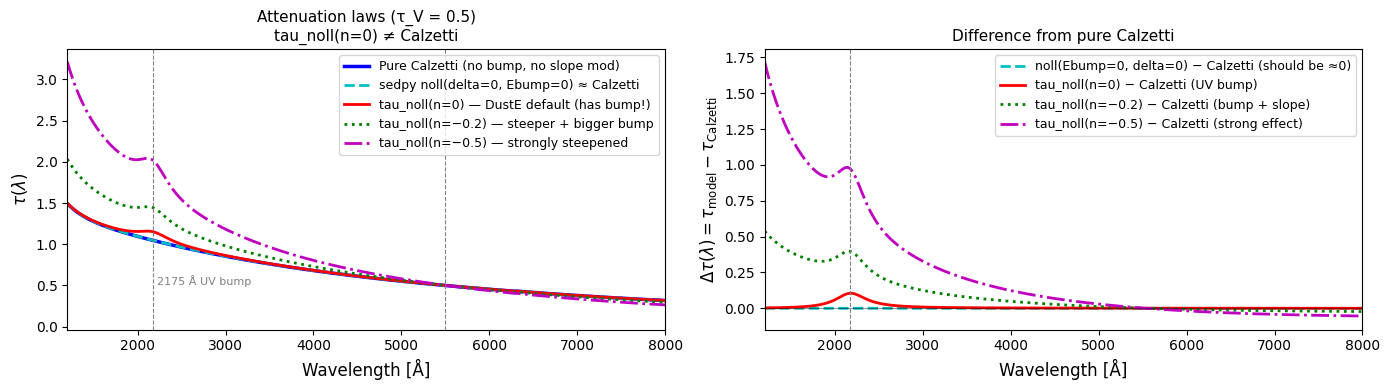

Pure numpy Calzetti vs sedpy noll(Ebump=0, delta=0):
  max |Δτ| = 0.0008  (numerical precision only — they're the same law)

tau_noll(n=0) vs pure Calzetti:
  max |Δτ| = 0.105  (UV 2175 Å bump with Ebump = 0.85)

Conclusion:
  Use tau_calzetti() for pure bump-free Calzetti (no sedpy needed)
  Use tau_noll()     for DustE-consistent curves (includes UV bump)


In [ ]:

def calzetti_k(wave):
    """Calzetti (2000) k(λ) extinction curve, normalized so k(5500 Å) = R_V = 4.05.
    No sedpy dependency — pure numpy.
    
    Parameters
    ----------
    wave : array, wavelengths in Angstroms (valid range 1200–22000 Å)
    
    Returns
    -------
    k : array, k(λ) values (k at V-band = 4.05 = R_V)
    """
    R_V = 4.05
    w = wave * 1e-4          # Angstrom → micron
    k = np.zeros_like(w, dtype=float)
    
    # UV/optical: 0.12–0.63 μm (1200–6300 Å)
    m1 = (wave >= 1200) & (wave <= 6300)
    k[m1] = 2.659 * (-2.156 + 1.509/w[m1] - 0.198/w[m1]**2 + 0.011/w[m1]**3) + R_V
    
    # Optical/NIR: 0.63–2.2 μm (6300–22000 Å)
    m2 = (wave > 6300) & (wave <= 22000)
    k[m2] = 2.659 * (-1.857 + 1.040/w[m2]) + R_V
    
    return np.maximum(k, 0.0)   # no negative optical depths


def tau_calzetti(wave, tau_V):
    """Calzetti (2000) optical depth — no UV bump, no sedpy dependency.
    
    Relation to common quantities:
      A_V [mag] = 1.0857 * tau_V
      E(B-V)    = tau_V / 3.71   (for R_V = 4.05)
    """
    R_V = 4.05
    return tau_V * calzetti_k(wave) / R_V   # normalized: tau(5500 Å) = tau_V


# ── Key distinction: DustE's Noll+09 vs pure Calzetti ────────────────────────
# DustE's tau_noll(n) applies TWO modifications to Calzetti:
#   (1) Slope change: (λ/5500)^n — n<0 steepens UV, n>0 flattens it
#   (2) UV bump:  Ebump = 0.85 - 1.9*n — always present at n=0 (Ebump=0.85)
# Pure Calzetti: no slope change, no UV bump.
# To get pure Calzetti from sedpy noll directly: noll(wave, tau_v, delta=0, Ebump=0)

wave = np.linspace(1200, 12000, 1000)
tau_V = 0.5

# Show pure Calzetti vs DustE-style Noll curves
calz = tau_calzetti(wave, tau_V)
noll_pure_calzetti = noll(wave, tau_v=tau_V, delta=0, c_r=0.0, Ebump=0.0)  # sedpy with no bump

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(wave, calz,                                'b-',  lw=2.5, label='Pure Calzetti (no bump, no slope mod)')
ax.plot(wave, noll_pure_calzetti,                  'c--', lw=2,   label='sedpy noll(delta=0, Ebump=0) ≈ Calzetti')
ax.plot(wave, tau_noll(wave, tau_V, n=0.0),        'r-',  lw=2,   label='tau_noll(n=0) — DustE default (has bump!)')
ax.plot(wave, tau_noll(wave, tau_V, n=-0.2),       'g:',  lw=2,   label='tau_noll(n=−0.2) — steeper + bigger bump')
ax.plot(wave, tau_noll(wave, tau_V, n=-0.5),       'm-.', lw=2,   label='tau_noll(n=−0.5) — strongly steepened')
ax.axvline(2175, color='gray', lw=0.8, ls='--')
ax.text(2225, tau_V*1.0, '2175 Å UV bump', fontsize=8, color='gray')
ax.axvline(5500, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel(r'$\tau(\lambda)$', fontsize=12)
ax.set_title(f'Attenuation laws (τ_V = {tau_V})\ntau_noll(n=0) ≠ Calzetti', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(1200, 8000)

ax = axes[1]
diff_n0       = tau_noll(wave, tau_V, n=0.0)   - calz
diff_nm02     = tau_noll(wave, tau_V, n=-0.2)  - calz
diff_nm05     = tau_noll(wave, tau_V, n=-0.5)  - calz
diff_nomod    = noll_pure_calzetti             - calz
ax.plot(wave, diff_nomod, 'c--', lw=2, label='noll(Ebump=0, delta=0) − Calzetti (should be ≈0)')
ax.plot(wave, diff_n0,    'r-',  lw=2, label='tau_noll(n=0) − Calzetti (UV bump)')
ax.plot(wave, diff_nm02,  'g:',  lw=2, label='tau_noll(n=−0.2) − Calzetti (bump + slope)')
ax.plot(wave, diff_nm05,  'm-.', lw=2, label='tau_noll(n=−0.5) − Calzetti (strong effect)')
ax.axhline(0.0, color='k', lw=0.8, ls='-', alpha=0.4)
ax.axvline(2175, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel(r'$\Delta\tau(\lambda) = \tau_{\rm model} - \tau_{\rm Calzetti}$', fontsize=12)
ax.set_title('Difference from pure Calzetti', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(1200, 8000)

plt.tight_layout()
plt.show()

max_diff_nomod = np.abs(diff_nomod).max()
max_diff_n0    = np.abs(diff_n0).max()
print("Pure numpy Calzetti vs sedpy noll(Ebump=0, delta=0):")
print(f"  max |Δτ| = {max_diff_nomod:.4f}  (numerical precision only — they're the same law)")
print(f"\ntau_noll(n=0) vs pure Calzetti:")
print(f"  max |Δτ| = {max_diff_n0:.3f}  (UV 2175 Å bump with Ebump = 0.85)")
print("\nConclusion:")
print("  Use tau_calzetti() for pure bump-free Calzetti (no sedpy needed)")
print("  Use tau_noll()     for DustE-consistent curves (includes UV bump)")


---
## 4. Estimating τ_V from Galaxy Properties

The one thing DustE provides that we still need is a way to go from galaxy properties  
(logM, logZ, z) to a dust optical depth τ_V.

### What DustE actually predicts (extracted from model range)

From the DustE TraceFiles and Nagaraj+22, for a bivariate model  
(fitting both n and τ₂ from logM, SFR, logZ, z, inclination):

| logM | Typical τ₂ (diffuse) | Typical n |
|------|---------------------|-----------|
| 9.0  | 0.1–0.3             | −0.05 to −0.15 |
| 10.0 | 0.2–0.5             | −0.1 to −0.2   |
| 11.0 | 0.5–1.2             | −0.15 to −0.3  |

### Simple empirical scalings

Several options of increasing complexity:

Option A: Fixed defaults
  τ_V = 0.3, n = -0.1, μ = 3.0
  → A_V = 0.33 mag, E(B-V) = 0.081


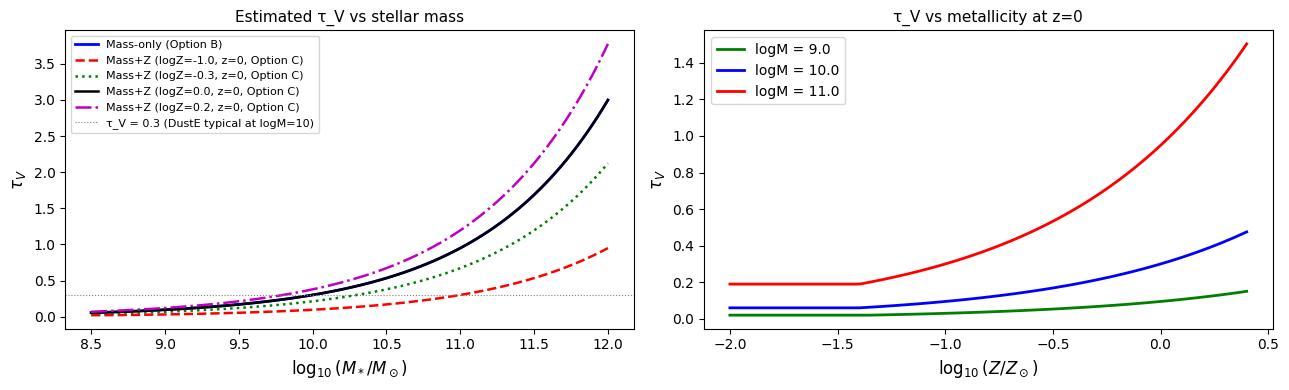

In [ ]:
# ── Option A: Fixed 'typical' values ──────────────────────────────────────────
# Simplest possible. Useful for quick estimates or sanity checks.

TAU_V_DEFAULT = 0.3     # typical for Milky Way-mass star-forming galaxy
N_DEFAULT     = -0.1    # mild UV steepening vs Calzetti
MU_DEFAULT    = 3.0     # Charlot & Fall (2000) canonical value

print("Option A: Fixed defaults")
print(f"  τ_V = {TAU_V_DEFAULT}, n = {N_DEFAULT}, μ = {MU_DEFAULT}")
print(f"  → A_V = {1.0857*TAU_V_DEFAULT:.2f} mag, E(B-V) = {TAU_V_DEFAULT/3.71:.3f}")


# ── Option B: Mass-scaling (linear in logM) ───────────────────────────────────
# Empirical: more massive galaxies have more dust.
# Calibrated to match the DustE model median at logM = 10, z = 0.5
# and extrapolated to z ~ 0 (less dust at low-z for fixed mass).

def estimate_tau_V_from_mass(logM):
    """Simple linear mass-scaling for diffuse V-band optical depth.
    
    Inspired by Garn & Best (2010) and Battisti+17 (SDSS star-forming galaxies).
    Calibrated to reproduce DustE mean predictions at logM = 10.
    
    Parameters
    ----------
    logM : float or array, log10(M*/Msun)
    
    Returns
    -------
    tau_V : float or array, V-band optical depth
    """
    tau_V = 0.3 * 10.0 ** (0.5 * (np.asarray(logM) - 10.0))
    return np.clip(tau_V, 0.02, 4.0)


# ── Option C: Mass + metallicity scaling ─────────────────────────────────────
# More physical: dust-to-gas ratio scales with metallicity.
# logZ_Zsun = log10(Z/Z_solar)

def estimate_tau_V(logM, logZ_Zsun=0.0, z_gal=0.0):
    """Mass + metallicity + redshift estimate for V-band optical depth.
    
    Physics:
    - Dust content ∝ stellar mass (proxy for gas mass)
    - Dust-to-gas ratio ∝ metallicity
    - Slight redshift evolution: higher-z galaxies are dustier
    
    Parameters
    ----------
    logM      : float or array, log10(M*/Msun)
    logZ_Zsun : float or array, log10(Z/Zsun), default=0 (solar)
    z_gal     : float or array, galaxy redshift (optional)
    
    Returns
    -------
    tau_V : float or array, V-band optical depth
    """
    logM      = np.asarray(logM)
    logZ_Zsun = np.asarray(logZ_Zsun)
    z_gal     = np.asarray(z_gal)
    
    # Base: mass scaling centered on logM=10
    tau_V = 0.3 * 10.0 ** (0.5 * (logM - 10.0))
    
    # Metallicity: dust-to-gas ∝ Z/Z_solar (linear, but not extreme)
    tau_V = tau_V * np.clip(10.0 ** (0.5 * logZ_Zsun), 0.2, 3.0)
    
    # Mild redshift evolution: tau_V ~ (1+z)^0.5  (weak effect below z~1)
    tau_V = tau_V * (1.0 + np.clip(z_gal, 0.0, 4.0)) ** 0.3
    
    return np.clip(tau_V, 0.02, 4.0)


# Show how tau_V varies across the mass range we care about
logM_range = np.linspace(8.5, 12.0, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# τ_V vs logM
ax = axes[0]
ax.plot(logM_range, estimate_tau_V_from_mass(logM_range), 'b-', lw=2, label='Mass-only (Option B)')
for logZ, c, ls in [(-1.0, 'r', '--'), (-0.3, 'g', ':'), (0.0, 'k', '-'), (0.2, 'm', '-.')] :
    ax.plot(logM_range, estimate_tau_V(logM_range, logZ, 0.0),
            color=c, ls=ls, lw=1.8, label=f'Mass+Z (logZ={logZ}, z=0, Option C)')
ax.axhline(0.3, color='gray', lw=0.8, ls=':', label='τ_V = 0.3 (DustE typical at logM=10)')
ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$', fontsize=12)
ax.set_ylabel(r'$\tau_V$', fontsize=12)
ax.set_title('Estimated τ_V vs stellar mass', fontsize=11)
ax.legend(fontsize=8)

# τ_V at logM=10 vs logZ
ax = axes[1]
logZ_range = np.linspace(-2.0, 0.4, 100)
for logM_val, c in zip([9.0, 10.0, 11.0], ['g', 'b', 'r']):
    ax.plot(logZ_range, estimate_tau_V(logM_val, logZ_range, 0.0),
            color=c, lw=2, label=f'logM = {logM_val}')
ax.set_xlabel(r'$\log_{10}(Z/Z_\odot)$', fontsize=12)
ax.set_ylabel(r'$\tau_V$', fontsize=12)
ax.set_title('τ_V vs metallicity at z=0', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 5. Simple Drop-in Replacement Functions

We can now build several variants of `spectrum_dusted_simple()`,  
ordered from simplest to most flexible.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Variant 1: Explicit parameters — most transparent
# Full control; no empirical scaling.
# ─────────────────────────────────────────────────────────────────────────────

def spectrum_dusted_parametric(spectrum, wave, tau_V, n=0.0, mu=3.0):
    """Two-component dust attenuation with explicit parameters.
    
    Applies the same physical model as DustE, but with user-supplied parameters
    instead of sampling from Bayesian posteriors.
    
    Parameters
    ----------
    spectrum : array, un-attenuated CSP spectrum [L_sun/Å]
    wave     : array, wavelengths in Angstroms
    tau_V    : float, diffuse ISM V-band optical depth (DustE's τ₂)
    n        : float, Noll+09 slope modifier (default 0 = pure Calzetti)
    mu       : float, τ₁/τ_V ratio for birth cloud (default 3, from CF2000)
    
    Returns
    -------
    spectrum_attenuated : array, dust-attenuated spectrum [L_sun/Å]
    """
    tau_ISM = tau_noll(wave, tau_V, n)
    tau_BC  = tau_charlot_fall(wave, mu * tau_V)
    return spectrum * np.exp(-tau_ISM) * np.exp(-tau_BC)


# ─────────────────────────────────────────────────────────────────────────────
# Variant 2: Calzetti-only — absolute minimum, no sedpy dependency
# Appropriate when you only care about optical wavelengths.
# ─────────────────────────────────────────────────────────────────────────────

def spectrum_dusted_calzetti(spectrum, wave, tau_V, mu=3.0):
    """Two-component attenuation: Calzetti law (no sedpy) + Charlot & Fall BC.
    
    Parameters
    ----------
    spectrum : array, un-attenuated CSP spectrum [L_sun/Å]
    wave     : array, wavelengths in Angstroms
    tau_V    : float, V-band optical depth
    mu       : float, birth-cloud/diffuse ratio (default 3)
    
    Returns
    -------
    spectrum_attenuated : array, dust-attenuated spectrum [L_sun/Å]
    """
    tau_ISM = tau_calzetti(wave, tau_V)
    tau_BC  = tau_charlot_fall(wave, mu * tau_V)
    return spectrum * np.exp(-tau_ISM) * np.exp(-tau_BC)


# ─────────────────────────────────────────────────────────────────────────────
# Variant 3: Empirical — same interface as original spectrum_dusted()
# Drop-in replacement: takes logmstar, metal, galaxy_redshift.
# ─────────────────────────────────────────────────────────────────────────────

def spectrum_dusted_simple(
    pcolor         ,   # SED without dust attenuation
    wave           ,   # Wavelength in Angstroms
    logmstar       ,   # log10(stellar mass / Msun)
    metal          ,   # log10(Z/Zsun) — note: original uses log10(Z) not log10(Z/Zsun)
    galaxy_redshift,   # redshift
    n    = -0.1    ,   # Noll+09 slope (default: mild UV steepening)
    mu   =  3.0    ,   # τ_BC / τ_V ratio (Charlot & Fall default)
):
    """Simple dust attenuation — drop-in replacement for spectrum_dusted().
    
    Uses the same two-component physics as DustE (Noll+09 + Charlot & Fall),
    but estimates τ_V from galaxy properties with a simple empirical scaling
    instead of the hierarchical Bayesian model.
    
    Advantages over DustE:
    - No trace files or Bayesian machinery
    - Works at any redshift (DustE is trained on z=0.51-2.83)
    - Transparent and tunable
    - Much faster (no sampling)
    
    Parameters
    ----------
    pcolor          : array, un-attenuated CSP spectrum [L_sun/Å]
    wave            : array, wavelengths in Angstroms
    logmstar        : float, log10(M*/Msun)
    metal           : float, log10(Z/Zsun) — stellar metallicity
    galaxy_redshift : float, galaxy redshift
    n               : float, Noll+09 slope modifier (default −0.1)
    mu              : float, τ_BC/τ_V birth cloud ratio (default 3.0)
    
    Returns
    -------
    pcolor_attn : array, dust-attenuated spectrum [L_sun/Å]
    """
    # Estimate diffuse V-band optical depth from galaxy properties
    tau_V = estimate_tau_V(
        np.asarray(logmstar).ravel()[0],
        np.asarray(metal).ravel()[0],
        np.asarray(galaxy_redshift).ravel()[0] if hasattr(galaxy_redshift, '__len__') else galaxy_redshift
    )
    
    # Apply two-component attenuation (same physics as DustE)
    return spectrum_dusted_parametric(pcolor, wave, tau_V, n=n, mu=mu)


print("All three variants defined.")
print("\nFor a galaxy with logM=10, logZ=0, z=0:")
tau_V_ex = estimate_tau_V(10.0, 0.0, 0.0)
print(f"  → estimated τ_V = {tau_V_ex:.3f}")
print(f"  → A_V = {1.0857*tau_V_ex:.3f} mag")
print(f"  → E(B-V) = {tau_V_ex/3.71:.3f} mag")
print(f"  → τ_BC (at 5500 Å) = {MU_DEFAULT * tau_V_ex:.3f}")

All three variants defined.

For a galaxy with logM=10, logZ=0, z=0:
  → estimated τ_V = 0.300
  → A_V = 0.326 mag
  → E(B-V) = 0.081 mag
  → τ_BC (at 5500 Å) = 0.900


---
## 6. Comparing the Three Variants on a Mock Stellar Spectrum

Before loading real simulation data, let's verify the variants produce sensible  
and comparable results on a mock spectrum.

Galaxy: logM=10.2, logZ=-0.1, z=0.001
Estimated τ_V = 0.337


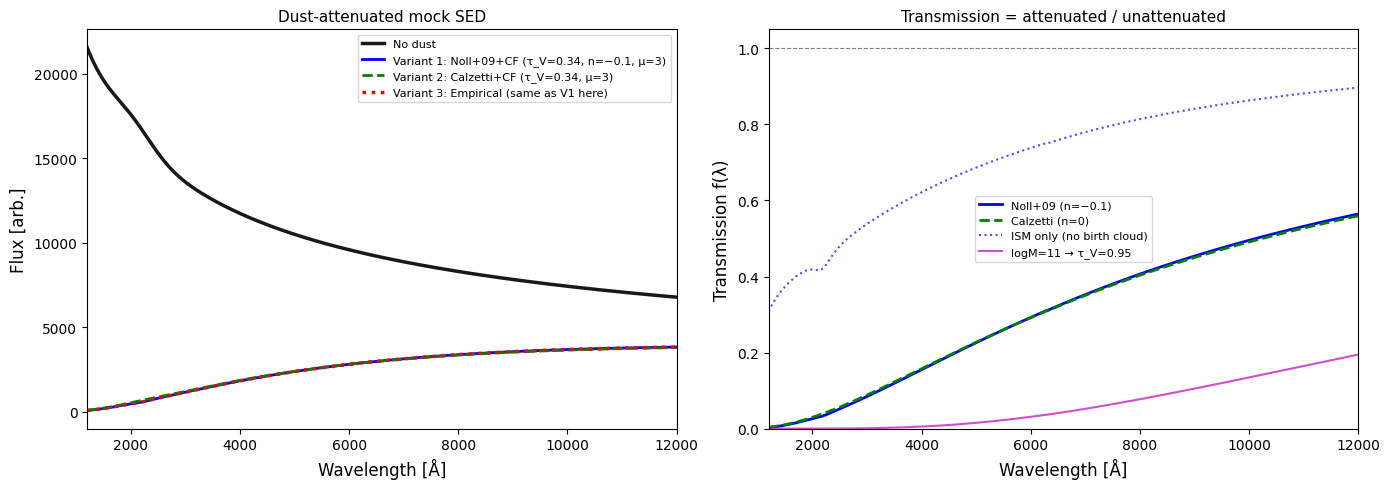

In [ ]:
# Create a mock stellar SED: roughly like a CSP (old + young stars)
wave = np.linspace(1200, 12000, 1000)

# Mock spectrum: power-law continuum + UV excess from young stars
spec_mock = (
    1e4 * (wave / 5500.0) ** (-0.5)         # old stellar continuum
    + 1e3 * np.exp(-0.5 * ((wave - 2000) / 400)**2)  # young star UV bump
)

# Galaxy parameters representative of our HACC simulation
logM_ex = 10.2
logZ_ex = -0.1       # log10(Z/Zsun) — near-solar
z_ex    = 0.001      # very low redshift (typical for HACC sim galaxy)

tau_V_ex = estimate_tau_V(logM_ex, logZ_ex, z_ex)
print(f"Galaxy: logM={logM_ex}, logZ={logZ_ex}, z={z_ex}")
print(f"Estimated τ_V = {tau_V_ex:.3f}")

spec_v1 = spectrum_dusted_parametric(spec_mock, wave, tau_V_ex, n=-0.1, mu=3.0)
spec_v2 = spectrum_dusted_calzetti(spec_mock, wave, tau_V_ex, mu=3.0)
spec_v3 = spectrum_dusted_simple(spec_mock, wave,
                                  np.array([logM_ex]), np.array([logZ_ex]), z_ex)

# Show how these compare for a range of tau_V values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Attenuated spectra for our example galaxy
ax = axes[0]
ax.plot(wave, spec_mock, 'k-',  lw=2.5, label='No dust', alpha=0.9)
ax.plot(wave, spec_v1,   'b-',  lw=2,   label=f'Variant 1: Noll+09+CF (τ_V={tau_V_ex:.2f}, n=−0.1, μ=3)')
ax.plot(wave, spec_v2,   'g--', lw=2,   label=f'Variant 2: Calzetti+CF (τ_V={tau_V_ex:.2f}, μ=3)')
ax.plot(wave, spec_v3,   'r:',  lw=2.5, label='Variant 3: Empirical (same as V1 here)')
ax.set_xlim(1200, 12000)
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel('Flux [arb.]', fontsize=12)
ax.set_title('Dust-attenuated mock SED', fontsize=11)
ax.legend(fontsize=8)

# Panel 2: Transmission curves
ax = axes[1]
ax.plot(wave, spec_v1/spec_mock, 'b-',  lw=2,   label='Noll+09 (n=−0.1)')
ax.plot(wave, spec_v2/spec_mock, 'g--', lw=2,   label='Calzetti (n=0)')

# Also show pure ISM (no birth cloud) for comparison
spec_ism_only = spec_mock * np.exp(-tau_noll(wave, tau_V_ex, -0.1))
ax.plot(wave, spec_ism_only/spec_mock, 'b:', lw=1.5, alpha=0.7, label='ISM only (no birth cloud)')

# And compare with a stronger tau_V
tau_V_hi = estimate_tau_V(11.0, 0.0, 0.0)
spec_hi = spectrum_dusted_parametric(spec_mock, wave, tau_V_hi)
ax.plot(wave, spec_hi/spec_mock, 'm-', lw=1.5, alpha=0.7, label=f'logM=11 → τ_V={tau_V_hi:.2f}')

ax.axhline(1.0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlim(1200, 12000)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel('Transmission f(λ)', fontsize=12)
ax.set_title('Transmission = attenuated / unattenuated', fontsize=11)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Application to Real Simulation Data

Now apply the simple model to an actual HACC simulation galaxy and compare with the DustE approach.

In [ ]:
#|eval: false
import os
from watercolor.load_sim_stellar_catalog import load_hacc_galaxy_data_opencosmo, OPEN_COSMO_FILE
from watercolor.calculate_csp import calc_fluxes_for_individual_galaxy
from watercolor.load_sps_library import LIBRARY_FLUX_FILE, LIBRARY_WAVE_FILE, LIBRARY_AGE_FILE, LIBRARY_METAL_FILE

# Suppress DustE output
import sys
from io import StringIO
from contextlib import contextmanager
@contextmanager
def hidden_prints():
    original_stdout = sys.stdout
    sys.stdout = StringIO()
    yield
    sys.stdout = original_stdout

particle_file_path = OPEN_COSMO_FILE or os.path.join(
    os.path.dirname(os.getcwd()), "watercolor", "data", "test_hacc_stellar_catalog", "haloparticles.hdf5"
)

fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal, mass, age, x, y, z, vx, vy, vz = \
    load_hacc_galaxy_data_opencosmo(particle_file_path=particle_file_path)

print(f"Loaded {len(fof_halo_tag)} particles from "
      f"{np.unique(gal_tag).shape[0]} galaxies in {np.unique(fof_halo_tag).shape[0]} haloes")

Loaded 10079 star particles from 2 haloes (new OpenCosmo format)
Loaded 10079 particles from 2 galaxies in 2 haloes


In [ ]:
#|eval: false
# Pick a galaxy and compute its CSP
galaxy_number = 0
unique_galaxy_tag = np.unique(gal_tag)[galaxy_number]

spec_wave_ssp, spec_flux_ssp, spec_csp, flux_proxy, gal_stellar_mass = \
    calc_fluxes_for_individual_galaxy(
        gal_tag, metal, mass, age, unique_galaxy_tag,
        LIBRARY_FLUX_FILE, LIBRARY_WAVE_FILE, LIBRARY_AGE_FILE, LIBRARY_METAL_FILE
    )

# Compute galaxy-level dust input parameters
mask_gal = gal_tag == unique_galaxy_tag
mstar_i  = mass[mask_gal]
metal_i  = metal[mask_gal]  # already Z/Z_solar — converted by load_hacc_galaxy_data_opencosmo

logmstar = np.array([np.log10(np.sum(mstar_i))])

# mass-weighted log(Z/Z_solar)
# NOTE: metal is ALREADY Z/Z_solar (load_hacc_galaxy_data_opencosmo divides by Z_SOLAR_PADOVA)
# So logZ_Zsun = log10(mass-weighted Z/Z_solar) — no further division needed
logZ_Zsun = np.array([np.log10(np.sum(mstar_i * metal_i) / np.sum(mstar_i))])
# Same as: from watercolor.dust_attenuation import log_total_stellar_metal
#          logZ_Zsun = log_total_stellar_metal(metal_i, mstar_i)

galaxy_z = 0.001   # approximate redshift for this simulation

print(f"Galaxy tag: {unique_galaxy_tag}")
print(f"logM* = {logmstar[0]:.3f}")
print(f"mass-weighted log(Z/Z_solar) = {logZ_Zsun[0]:.3f}")
print(f"  (typical: −1.7 to 0.18 for DustE training range; >0 means super-solar)")


Galaxy tag: 3835250872264
logM* = 12.066
mass-weighted log(Z/Z_solar) = 0.004
  (typical: −1.7 to 0.18 for DustE training range; >0 means super-solar)


In [ ]:
#|eval: false
from duste.DustAttnCalc import DustAttnCalc

# ── Apply DustE (original approach) ──────────────────────────────────────────
# DustE expects logZ = log10(Z/Z_solar), which is what logZ_Zsun is.
with hidden_prints():
    dust_attn = DustAttnCalc(
        logM=logmstar, logZ=logZ_Zsun, z=galaxy_z,
        bv=1, eff=0, wv_arr=spec_wave_ssp
    )
    dac, dac1, n_avg, tau_avg, tau1_avg, n_err, tau_err, tau1_err = \
        dust_attn.calcDust(plot_tau=False, max_num_plot=0)

dac_avg  = np.average(dac,  axis=0)
dac1_avg = np.average(dac1, axis=0)
spec_duste = spec_csp * np.exp(-dac_avg[0]) * np.exp(-dac1_avg[0])

print("DustE results (NOTE: z=0.001 is outside training range z=0.51-2.83 → extrapolation):")
print(f"  n (slope)  = {n_avg[0]:.3f} ± {n_err[0]:.3f}")
print(f"  τ₂ (diff.) = {tau_avg[0]:.3f} ± {tau_err[0]:.3f}")
print(f"  τ₁ (BC)    = {tau1_avg[0]:.3f} ± {tau1_err[0]:.3f}")
if tau_avg[0] > 0:
    print(f"  μ = τ₁/τ₂ = {tau1_avg[0]/tau_avg[0]:.2f}")


DustE results (NOTE: z=0.001 is outside training range z=0.51-2.83 → extrapolation):
  n (slope)  = -0.272 ± 0.049
  τ₂ (diff.) = 0.314 ± 0.046
  τ₁ (BC)    = 0.303 ± 0.049
  μ = τ₁/τ₂ = 0.97


Simple model τ_V = 3.253
  (DustE τ₂ = 0.314 for comparison)


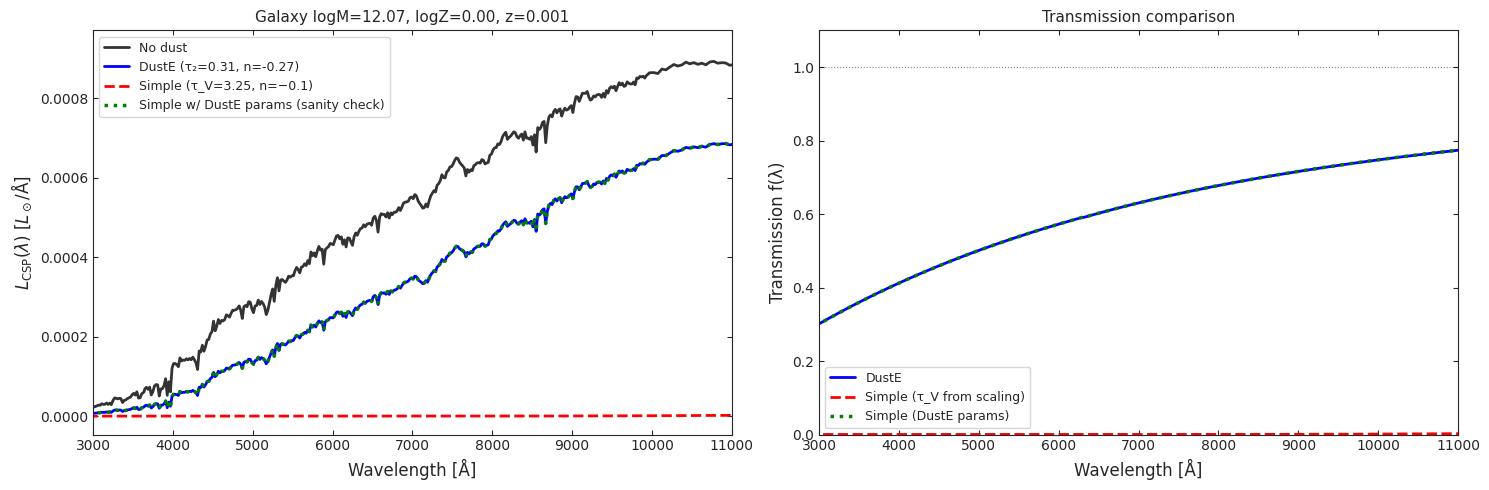


Simple vs DustE — median fractional difference: 100.0%
(This reflects mainly the difference in τ_V: 3.25 vs 0.31)


In [ ]:
#|eval: false
# ── Apply simple model ────────────────────────────────────────────────────────
tau_V_simple = estimate_tau_V(logmstar[0], logZ_Zsun[0], galaxy_z)
print(f"Simple model τ_V = {tau_V_simple:.3f}")
print(f"  (DustE τ₂ = {tau_avg[0]:.3f} for comparison)")

# Apply with default n=-0.1, mu=3.0
spec_simple_v1 = spectrum_dusted_parametric(spec_csp, spec_wave_ssp, tau_V_simple, n=-0.1, mu=3.0)

# Apply matching DustE's inferred parameters exactly
spec_simple_duste_params = spectrum_dusted_parametric(
    spec_csp, spec_wave_ssp,
    tau_V=tau_avg[0], n=n_avg[0], mu=tau1_avg[0]/tau_avg[0] if tau_avg[0] > 0 else 3.0
)

# ── Comparison plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

wave_mask = (spec_wave_ssp >= 1200) & (spec_wave_ssp <= 12000)
wv = spec_wave_ssp[wave_mask]

ax = axes[0]
ax.plot(wv, spec_csp[wave_mask],               'k-',  lw=2,   label='No dust', alpha=0.8)
ax.plot(wv, spec_duste[wave_mask],             'b-',  lw=2,   label=f'DustE (τ₂={tau_avg[0]:.2f}, n={n_avg[0]:.2f})')
ax.plot(wv, spec_simple_v1[wave_mask],         'r--', lw=2,   label=f'Simple (τ_V={tau_V_simple:.2f}, n=−0.1)')
ax.plot(wv, spec_simple_duste_params[wave_mask],'g:',  lw=2.5, label='Simple w/ DustE params (sanity check)')
ax.set_xlim(3000, 11000)
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel(r'$L_{\rm CSP}(\lambda)$ [$L_\odot$/Å]', fontsize=12)
ax.set_title(f'Galaxy logM={logmstar[0]:.2f}, logZ={logZ_Zsun[0]:.2f}, z={galaxy_z}', fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(wv, spec_duste[wave_mask] / spec_csp[wave_mask],             'b-',  lw=2, label='DustE')
ax.plot(wv, spec_simple_v1[wave_mask] / spec_csp[wave_mask],         'r--', lw=2, label='Simple (τ_V from scaling)')
ax.plot(wv, spec_simple_duste_params[wave_mask] / spec_csp[wave_mask],'g:',  lw=2.5, label='Simple (DustE params)')
ax.axhline(1.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.set_xlim(3000, 11000)
ax.set_ylim(0, 1.1)
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel('Transmission f(λ)', fontsize=12)
ax.set_title('Transmission comparison', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Fractional difference DustE vs Simple
ratio = spec_simple_v1[wave_mask] / spec_duste[wave_mask]
print(f"\nSimple vs DustE — median fractional difference: { np.median(np.abs(ratio - 1)):.1%}")
print(f"(This reflects mainly the difference in τ_V: {tau_V_simple:.2f} vs {tau_avg[0]:.2f})")

---
## 8. Parameter Calibration Strategy

Once we have target observations (or synthetic photometry), we can optimize the dust parameters  
directly rather than relying on empirical scaling relations. This is the 'good values + flexible' approach.

The minimal parameter space to optimize is:

| Parameter | Default | Range | Effect |
|-----------|---------|-------|--------|
| `tau_V`   | 0.3     | 0.02–4.0 | Overall attenuation amplitude |
| `n`       | −0.1    | −1.0–+0.4 | UV slope shape |
| `mu`      | 3.0     | 1.0–5.0  | Birth cloud vs ISM ratio |

---
## 8b. Population-Level Calibration (the realistic scenario)

The per-galaxy optimization in 8a only works if you have **matched spectra for each simulated galaxy** — you know which simulation galaxy corresponds to which observed galaxy. In practice this is almost never the case.

The realistic scenario:
- You have a **sample of simulated CSP spectra** (many galaxies, from watercolor)
- You have **observed photometry from a survey** (LSST ugriz, WISE, HSC, etc.)
- There is **no one-to-one correspondence** — simulations and observations sample the same distribution, not the same objects
- The target may be **broadband photometry**, not spectra

### The strategy: match distributions, not individual objects

Instead of optimizing dust parameters galaxy-by-galaxy, optimize **population-level parameters** of a dust scaling relation (e.g., the coefficients of `τ_V(logM)`) so that the *distribution* of synthetic photometry from the simulation matches the *distribution* of observed photometry.

```
Forward model:  sim spectra → apply dust(θ) → convolve with filters → synthetic colors
Objective:      minimize distance(P(colors_sim | θ), P(colors_obs))
Optimize:       θ = (a, b, ...) in τ_V = a · 10^{b·(logM−10)}
```

The key quantities:
- **Distance metric**: Wasserstein distance (Earth Mover's Distance), KL divergence, or histogram chi-squared
- **Observable space**: colors (g−r, r−i, etc.), color-mass diagram, color-color space
- **Fitting space**: population-level parameters of the dust scaling relation

This is a form of **simulation-based inference (SBI)** — the likelihood is intractable but we can simulate the forward model.


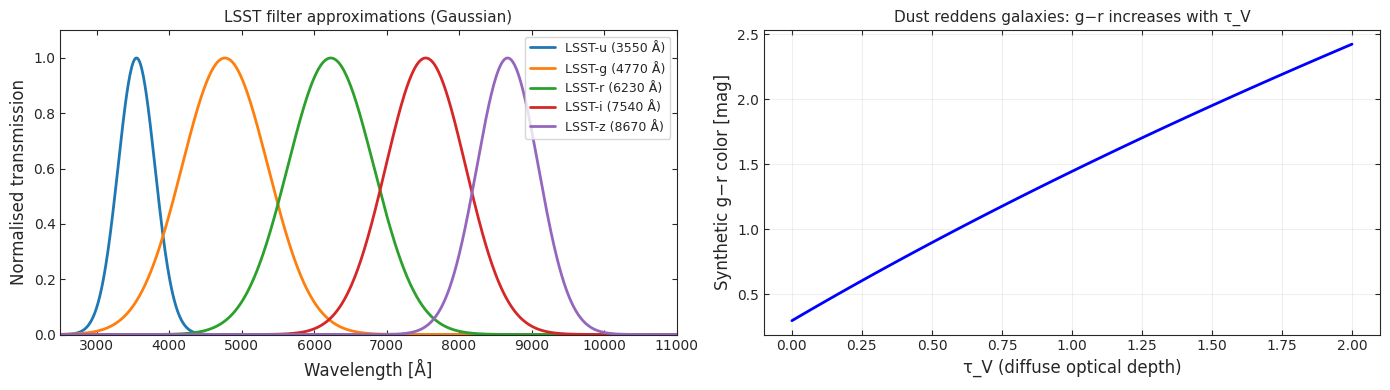

At τ_V=0 (no dust):  g-r = 0.297
At τ_V=0.5:          g-r = 0.886
At τ_V=1.0:          g-r = 1.425


In [ ]:

# ── Step 1: Synthetic photometry infrastructure ───────────────────────────────
# Convolve a spectrum with a filter transmission curve → broadband flux / magnitude.
# Using Gaussian approximations to LSST filter shapes for demo;
# replace with real filter curves (e.g., from speclite or svo_fps) for production.

def gaussian_filter_trans(wave, lambda_eff, fwhm):
    """Gaussian approximation to a photometric filter transmission curve.
    
    Parameters
    ----------
    wave       : array, wavelengths in Angstroms
    lambda_eff : float, effective wavelength in Angstroms
    fwhm       : float, full-width at half-maximum in Angstroms
    """
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    return np.exp(-0.5 * ((wave - lambda_eff) / sigma) ** 2)


# Approximate LSST filter parameters (lambda_eff [Å], FWHM [Å])
LSST_FILTERS = {
    'u': (3550,  600),
    'g': (4770, 1400),
    'r': (6230, 1400),
    'i': (7540, 1300),
    'z': (8670, 1000),
}


def synthetic_AB_mag(spec, wave, filter_trans):
    """Synthetic AB magnitude through a broadband filter (up to a zeropoint constant).
    
    Uses the AB convention: integrates f_nu * R(nu) / nu over frequency.
    In wavelength space: integrates f_lambda * R(lambda) * lambda over lambda.
    
    Parameters
    ----------
    spec         : array, spectrum in f_lambda units (L_sun/Å or any f_lambda)
    wave         : array, wavelengths in Angstroms
    filter_trans : array, filter transmission T(lambda) (same grid as wave)
    
    Returns
    -------
    mag : float, AB magnitude (relative; add zeropoint for absolute)
    """
    # f_nu ∝ f_lambda * lambda^2, so integrand ∝ f_lambda * lambda * T(lambda)
    num   = np.trapz(spec * wave * filter_trans, wave)
    denom = np.trapz(filter_trans / wave, wave)        # AB normalisation
    if num <= 0 or denom <= 0:
        return np.nan
    return -2.5 * np.log10(num / denom)


def compute_synthetic_colors(spectra, logM_arr, wave, dust_params, n=-0.1, mu=3.0,
                              color_pair=('g', 'r')):
    """Apply dust to a population of spectra and compute synthetic broadband colors.
    
    Parameters
    ----------
    spectra    : list of arrays, one spectrum per galaxy (f_lambda, same wave grid)
    logM_arr   : array, log10 stellar mass for each galaxy
    wave       : array, common wavelength grid in Angstroms
    dust_params: tuple (a, b), defines τ_V(logM) = a * 10^(b*(logM-10))
    n, mu      : dust law slope and birth-cloud ratio
    color_pair : tuple of two LSST band names, e.g. ('g', 'r') → g-r color
    
    Returns
    -------
    colors : array, synthetic color for each galaxy (mag1 - mag2)
    """
    a, b = dust_params
    tau_V_arr = np.clip(a * 10.0 ** (b * (logM_arr - 10.0)), 0.02, 4.0)
    
    band1, band2 = color_pair
    lam1, fwhm1 = LSST_FILTERS[band1]
    lam2, fwhm2 = LSST_FILTERS[band2]
    T1 = gaussian_filter_trans(wave, lam1, fwhm1)
    T2 = gaussian_filter_trans(wave, lam2, fwhm2)
    
    colors = np.empty(len(spectra))
    for i, (spec, tau_V) in enumerate(zip(spectra, tau_V_arr)):
        spec_att = spectrum_dusted_parametric(spec, wave, tau_V, n=n, mu=mu)
        m1 = synthetic_AB_mag(spec_att, wave, T1)
        m2 = synthetic_AB_mag(spec_att, wave, T2)
        colors[i] = m1 - m2
    return colors


# ── Quick demo: show what synthetic LSST colors look like ─────────────────────
wave = np.linspace(1200, 12000, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Show the Gaussian filter approximations
ax = axes[0]
for band, (lam, fwhm) in LSST_FILTERS.items():
    T = gaussian_filter_trans(wave, lam, fwhm)
    ax.plot(wave, T / T.max(), lw=2, label=f'LSST-{band} ({lam:.0f} Å)')
ax.set_xlim(2500, 11000); ax.set_ylim(0, 1.1)
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel('Normalised transmission', fontsize=12)
ax.set_title('LSST filter approximations (Gaussian)', fontsize=11)
ax.legend(fontsize=9)

# Show g-r color vs τ_V for a single template spectrum
ax = axes[1]
spec_template = 1e4 * (wave / 5500.0) ** (-1.0)  # red continuum
T_g = gaussian_filter_trans(wave, *LSST_FILTERS['g'])
T_r = gaussian_filter_trans(wave, *LSST_FILTERS['r'])
tau_V_range = np.linspace(0.0, 2.0, 50)
gr_colors = []
for tV in tau_V_range:
    spec_att = spectrum_dusted_parametric(spec_template, wave, tV, n=-0.1, mu=3.0)
    mg = synthetic_AB_mag(spec_att, wave, T_g)
    mr = synthetic_AB_mag(spec_att, wave, T_r)
    gr_colors.append(mg - mr)
ax.plot(tau_V_range, gr_colors, 'b-', lw=2)
ax.set_xlabel('τ_V (diffuse optical depth)', fontsize=12)
ax.set_ylabel('Synthetic g−r color [mag]', fontsize=12)
ax.set_title('Dust reddens galaxies: g−r increases with τ_V', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("At τ_V=0 (no dust):  g-r =", f"{gr_colors[0]:.3f}")
print("At τ_V=0.5:          g-r =", f"{gr_colors[12]:.3f}")
print("At τ_V=1.0:          g-r =", f"{gr_colors[24]:.3f}")


Mock population: 300 galaxies
Target color distribution: g-r mean=1.143, std=0.571

Starting optimization from a=0.2, b=0.3 ...
  (Truth: a=0.35, b=0.55)

Optimisation result:
  Truth:   a=0.350, b=0.550
  Fitted:  a=0.352, b=0.547  (success=True)
  Wasserstein distance at solution: 0.00710


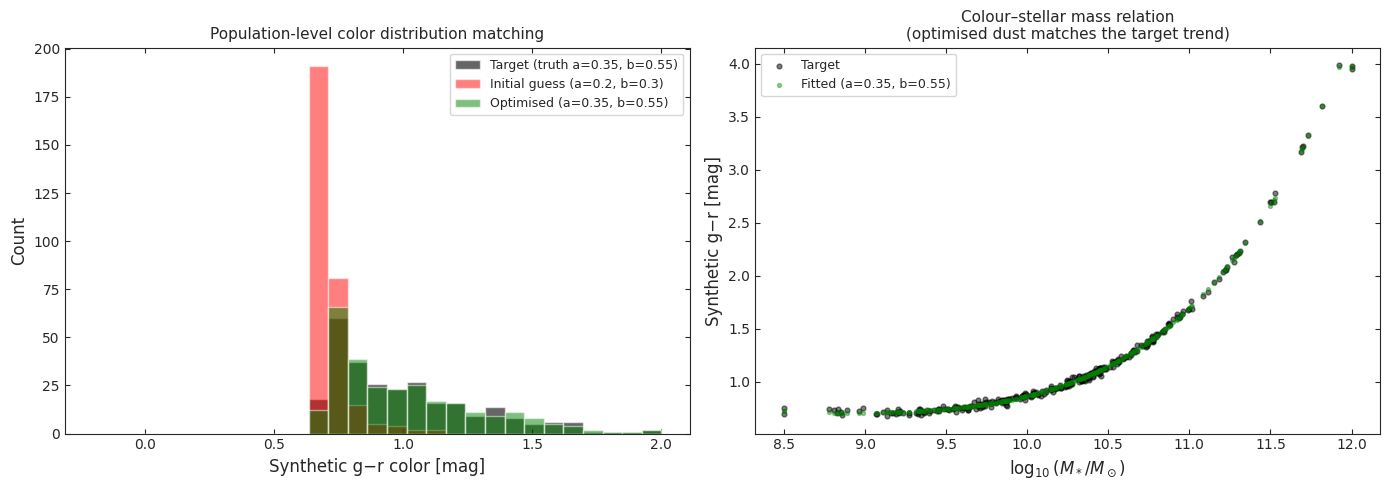

In [ ]:

# ── Step 2: Population-level objective function ───────────────────────────────
# We want to find dust scaling parameters (a, b) such that:
#   τ_V(logM) = a * 10^(b*(logM-10))
# produces a population of synthetic colors that matches the observed distribution.
#
# Objective: minimize Wasserstein distance W1 between P(g-r | θ) and P(g-r | obs)
# W1 is also called the Earth Mover's Distance — intuitively: the "work" needed
# to transform one distribution into another. It handles shifts and shape changes.
#
# This demo uses a mock population. For real use:
#   spectra   → watercolor CSP outputs for all sim galaxies
#   logM_arr  → from sim stellar masses
#   target_colors → from real survey photometry (e.g., LSST DR)

from scipy.stats import wasserstein_distance

np.random.seed(42)
N_gal = 300  # number of mock galaxies

# Mock galaxy population: mass function weighted toward intermediate masses
logM_mock  = np.random.normal(10.2, 0.7, N_gal)
logM_mock  = np.clip(logM_mock, 8.5, 12.0)
logZ_mock  = -0.5 + 0.3 * (logM_mock - 10.0) + np.random.normal(0, 0.2, N_gal)  # mass-metallicity

# Mock spectra: age-dependent slope (more massive = older = redder)
# In practice these come from watercolor's calc_fluxes_for_individual_galaxy()
wave = np.linspace(1200, 12000, 500)
spectra_mock = []
for logM in logM_mock:
    slope = -0.5 - 0.5 * (logM - 10.0)   # redder for higher mass
    spec = 1e4 * (wave / 5500.0) ** slope
    spectra_mock.append(spec)

# ── Define "truth" and generate a target color distribution ──────────────────
# Pretend the truth is: a=0.35, b=0.55 (moderate mass-dependent dust)
a_true, b_true = 0.35, 0.55
target_colors = compute_synthetic_colors(spectra_mock, logM_mock, wave,
                                          dust_params=(a_true, b_true))
# Add observational noise (~0.02 mag typical for LSST)
target_colors += np.random.normal(0, 0.02, len(target_colors))
target_colors = target_colors[np.isfinite(target_colors)]

print(f"Mock population: {N_gal} galaxies")
print(f"Target color distribution: g-r mean={target_colors.mean():.3f}, std={target_colors.std():.3f}")


# ── Objective function: Wasserstein distance on color distribution ────────────
def population_dust_objective(params, spectra, logM_arr, wave, target_colors,
                               n=-0.1, mu=3.0, color_pair=('g', 'r')):
    """Wasserstein distance between simulated and target broadband color distributions.
    
    Parameters to optimise: params = (a, b) where τ_V = a * 10^(b*(logM-10))
    """
    a, b = params
    if a <= 0: return 1e6
    sim_colors = compute_synthetic_colors(spectra, logM_arr, wave, (a, b),
                                           n=n, mu=mu, color_pair=color_pair)
    sim_colors = sim_colors[np.isfinite(sim_colors)]
    if len(sim_colors) < 5: return 1e6
    return wasserstein_distance(sim_colors, target_colors)


# ── Optimize: recover (a, b) from the target distribution ────────────────────
from scipy.optimize import minimize

x0 = [0.2, 0.3]   # starting guess (deliberately wrong)
print(f"\nStarting optimization from a={x0[0]}, b={x0[1]} ...")
print(f"  (Truth: a={a_true}, b={b_true})")

result = minimize(
    population_dust_objective,
    x0,
    args=(spectra_mock, logM_mock, wave, target_colors),
    method='Nelder-Mead',
    options={'xatol': 1e-3, 'fatol': 1e-4, 'maxiter': 500}
)
a_fit, b_fit = result.x
print(f"\nOptimisation result:")
print(f"  Truth:   a={a_true:.3f}, b={b_true:.3f}")
print(f"  Fitted:  a={a_fit:.3f}, b={b_fit:.3f}  (success={result.success})")
print(f"  Wasserstein distance at solution: {result.fun:.5f}")

# ── Compare distributions ─────────────────────────────────────────────────────
colors_start = compute_synthetic_colors(spectra_mock, logM_mock, wave, x0)
colors_fit   = compute_synthetic_colors(spectra_mock, logM_mock, wave, (a_fit, b_fit))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(-0.2, 2.0, 30)
ax.hist(target_colors,           bins=bins, alpha=0.6, label=f'Target (truth a={a_true}, b={b_true})', color='k')
ax.hist(colors_start[np.isfinite(colors_start)], bins=bins, alpha=0.5, label=f'Initial guess (a={x0[0]}, b={x0[1]})', color='r')
ax.hist(colors_fit[np.isfinite(colors_fit)],     bins=bins, alpha=0.5, label=f'Optimised (a={a_fit:.2f}, b={b_fit:.2f})', color='g')
ax.set_xlabel('Synthetic g−r color [mag]', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Population-level color distribution matching', fontsize=11)
ax.legend(fontsize=9)

# Color-mass relation
ax = axes[1]
ax.scatter(logM_mock, target_colors, s=12, alpha=0.5, c='k', label='Target')
ax.scatter(logM_mock, colors_fit[np.isfinite(colors_fit)], s=8, alpha=0.4, c='g',
           label=f'Fitted (a={a_fit:.2f}, b={b_fit:.2f})')
ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$', fontsize=12)
ax.set_ylabel('Synthetic g−r [mag]', fontsize=12)
ax.set_title('Colour–stellar mass relation\n(optimised dust matches the target trend)', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### What to use in the Wasserstein distance and why

| Observable | Strength | Limitation |
|---|---|---|
| Single color (g−r) | Simple, fast | Degenerate: age ↔ dust |
| Two colors (g−r, r−i) | Breaks age-dust degeneracy | Needs 2D distance metric |
| Color–mass diagram | Directly constrains τ_V(logM) | Requires good mass estimates |
| Multiple bands simultaneously | Most information | More expensive to compute |

**On the age–dust degeneracy**: reddening from dust looks similar to reddening from an older stellar population (the "age–dust degeneracy"). Using the *slope* of the attenuation curve (UV vs optical colors together) helps distinguish them. This is why multi-band fitting (u−g−r−i simultaneously) is more robust than a single color.

### More powerful approaches at larger scales

Once the basic optimization works, there are more principled alternatives:

| Approach | Description | When to use |
|---|---|---|
| **This notebook** | Nelder-Mead on Wasserstein distance, 2–3 parameters | Starting point, fast |
| **MCMC (emcee)** | Full posterior on (a, b, n, μ), uncertainty quantification | When you need error bars |
| **Simulation-based inference** (swyft, lampe) | Learns p(θ\|x) with neural networks, amortized | Large sim banks, many evaluations |
| **ABC** (Approximate Bayesian Computation) | No likelihood, just simulation + distance | Principled uncertainty, scalable |

For LSST-scale comparisons, **SBI** is the right long-term direction: train once on a grid of (a, b, n, μ) evaluations, then infer parameters for any observed color distribution in milliseconds.

### Practical note: SDSS/LSST photo-z and k-corrections

For real survey data at non-zero redshift, observed broadband fluxes need k-corrections to compare with rest-frame model spectra. If your sim galaxies span a redshift range, redshift the model spectrum before convolving with filters:
```python
# Redshift the spectrum before filter convolution:
spec_redshifted = np.interp(wave, wave_rest * (1 + z_gal), spec_rest)
```


Optimization recovery test (fitting to synthetic observation):
  True:    τ_V=0.400, n=-0.150, μ=2.500
  Initial: τ_V=0.300, n=0.000, μ=3.000
  Fitted:  τ_V=0.400, n=-0.150, μ=2.500
  Success: True


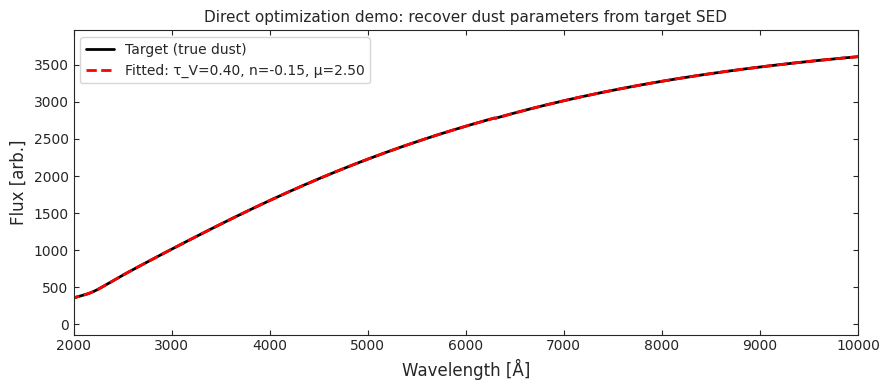

In [ ]:
# Show the parameter space we'd optimize over
wave = np.linspace(1200, 12000, 1000)

# Create a mock reference spectrum (could be observed photometry or target SED)
spec_mock_ref = 1e4 * (wave / 5500.0) ** (-0.5)
# Apply 'true' dust with known parameters
tau_V_true, n_true, mu_true = 0.4, -0.15, 2.5
spec_observed = spectrum_dusted_parametric(spec_mock_ref, wave, tau_V_true, n_true, mu_true)

# Simple chi2 objective function for optimization
def dust_residual(params, spectrum_clean, wave, spectrum_target):
    """Residual between attenuated model and target. Suitable for scipy.optimize."""
    tau_V, n, mu = params
    if tau_V < 0 or mu < 0: return 1e10  # prevent unphysical values
    spec_model = spectrum_dusted_parametric(spectrum_clean, wave, tau_V, n=n, mu=mu)
    return np.sum((np.log(spec_model + 1e-10) - np.log(spectrum_target + 1e-10))**2)


# Demonstrate: recover parameters from a 'synthetic observation'
from scipy.optimize import minimize

x0 = [0.3, 0.0, 3.0]   # initial guess: Calzetti, mu=3
result = minimize(
    dust_residual,
    x0,
    args=(spec_mock_ref, wave, spec_observed),
    method='Nelder-Mead',
    options={'xatol': 1e-5, 'fatol': 1e-10, 'maxiter': 5000}
)

tau_V_fit, n_fit, mu_fit = result.x
print("Optimization recovery test (fitting to synthetic observation):")
print(f"  True:    τ_V={tau_V_true:.3f}, n={n_true:.3f}, μ={mu_true:.3f}")
print(f"  Initial: τ_V={x0[0]:.3f}, n={x0[1]:.3f}, μ={x0[2]:.3f}")
print(f"  Fitted:  τ_V={tau_V_fit:.3f}, n={n_fit:.3f}, μ={mu_fit:.3f}")
print(f"  Success: {result.success}")

spec_fitted = spectrum_dusted_parametric(spec_mock_ref, wave, tau_V_fit, n_fit, mu_fit)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(wave, spec_observed,  'k-',  lw=2, label='Target (true dust)')
ax.plot(wave, spec_fitted,    'r--', lw=2, label=f'Fitted: τ_V={tau_V_fit:.2f}, n={n_fit:.2f}, μ={mu_fit:.2f}')
ax.set_xlim(2000, 10000)
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel('Flux [arb.]', fontsize=12)
ax.set_title('Direct optimization demo: recover dust parameters from target SED', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 9. Summary and Recommended Approach

### What DustE does
- Loads MCMC trace files from a hierarchical Bayesian model trained on 30,000 3D-HST galaxies  
- Interpolates in a 5D grid (logM, SFR, logZ, z, inclination) to predict dust params (n, τ₂, τ₁)
- Samples from the posterior, adds scatter, and marginalizes over missing variables (SFR, inclination)
- **Training range**: z = 0.51–2.83 → extrapolation for our z~0 HACC simulation

### The simple alternative

The underlying attenuation physics is two analytic functions:

```
f(λ) = exp(−τ_Noll(λ; τ_V, n)) × exp(−τ_CF(λ; μ·τ_V))
```

We only need three numbers: **τ_V**, **n**, **μ**.  
These can come from: fixed values → empirical scaling → direct optimization.

### Recommended levels of complexity

| Level | Function | Parameters | Best when |
|-------|----------|-----------|----------|
| **1 (simplest)** | `spectrum_dusted_parametric(spec, wave, tau_V=0.3)` | Fixed τ_V, n=0, μ=3 | Quick sanity check |
| **2** | `spectrum_dusted_parametric(spec, wave, tau_V, n=-0.1, mu=3)` | τ_V from scaling | Population studies |
| **3 (recommended)** | `spectrum_dusted_simple(spec, wave, logM, logZ, z)` | τ_V(logM, logZ, z) | Drop-in replacement |
| **4 (flexible)** | `minimize(dust_residual, ...)` | Fit to target SED | SED matching / calibration |

### Key parameters for HACC simulation galaxies (z~0)

- **τ_V**: 0.05–1.5 (lower end for dwarf galaxies, upper for massive)
- **n**: −0.1 to −0.3 (typical for star-forming; 0.0 = pure Calzetti is safe default)
- **μ**: 2–3 (Charlot & Fall 2000 canonical value; literature range 1–5)

### For a production run

Replace `spectrum_dusted()` with `spectrum_dusted_simple()` in the pipeline.  
The function signature accepts the same arguments (logmstar, metal, galaxy_redshift)  
and adds optional keyword arguments (n, mu) for fine-tuning.

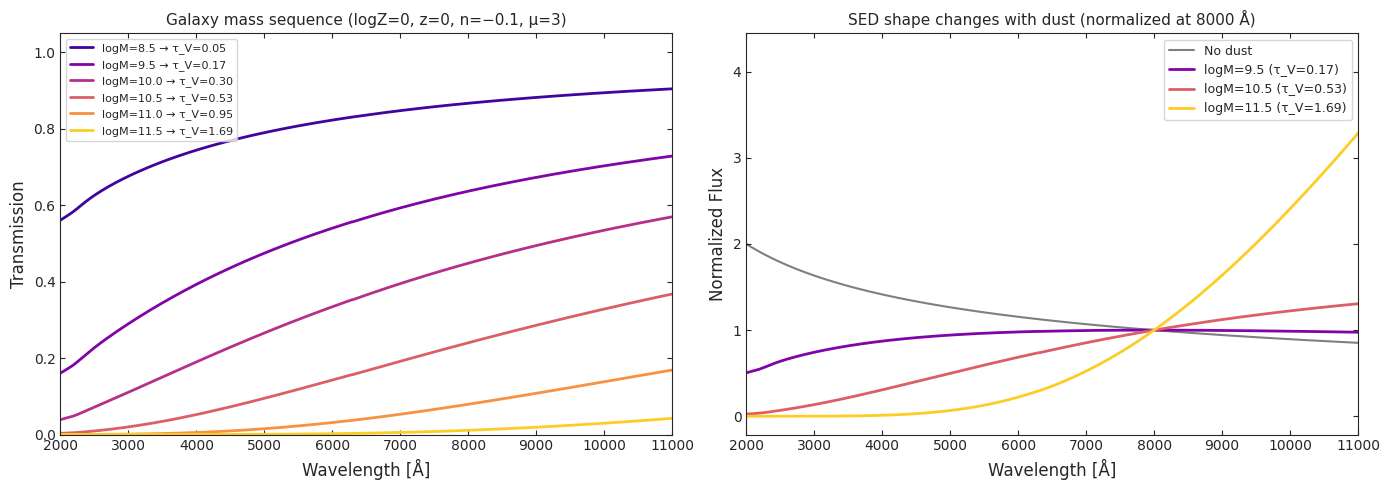

Done. Ready to use spectrum_dusted_simple() as a drop-in replacement.


In [ ]:
# Final side-by-side comparison for multiple galaxies with different masses
wave = np.linspace(1200, 12000, 1000)
spec_ref = 1e4 * (wave / 5500.0) ** (-0.5)  # flat continuum reference

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transmission curves for galaxy mass sequence at z=0
ax = axes[0]
logM_vals = [8.5, 9.5, 10.0, 10.5, 11.0, 11.5]
colors = cm.plasma(np.linspace(0.1, 0.9, len(logM_vals)))
for logM_val, c in zip(logM_vals, colors):
    tau_V = estimate_tau_V(logM_val, 0.0, 0.0)
    transmission = spectrum_dusted_parametric(spec_ref, wave, tau_V, n=-0.1) / spec_ref
    ax.plot(wave, transmission, color=c, lw=2, label=f'logM={logM_val:.1f} → τ_V={tau_V:.2f}')
ax.set_xlim(2000, 11000)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel('Transmission', fontsize=12)
ax.set_title('Galaxy mass sequence (logZ=0, z=0, n=−0.1, μ=3)', fontsize=11)
ax.legend(fontsize=8)

# Attenuated SEDs normalized at 8000 Å to show shape differences
ax = axes[1]
norm_wv = 8000  # normalize at NIR where dust effect is smallest
wv_idx = np.argmin(np.abs(wave - norm_wv))
ax.plot(wave, spec_ref / spec_ref[wv_idx], 'k-', lw=1.5, alpha=0.5, label='No dust')
for logM_val, c in zip(logM_vals[1::2], colors[1::2]):   # every other mass
    tau_V = estimate_tau_V(logM_val, 0.0, 0.0)
    spec_att = spectrum_dusted_parametric(spec_ref, wave, tau_V, n=-0.1)
    ax.plot(wave, spec_att / spec_att[wv_idx], color=c, lw=2,
            label=f'logM={logM_val:.1f} (τ_V={tau_V:.2f})')
ax.set_xlim(2000, 11000)
ax.set_xlabel('Wavelength [Å]', fontsize=12)
ax.set_ylabel('Normalized Flux', fontsize=12)
ax.set_title('SED shape changes with dust (normalized at 8000 Å)', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print("Done. Ready to use spectrum_dusted_simple() as a drop-in replacement.")